# FrenchMedMCQA — Analyse Exploratoire (EDA)

## Synthèse & Observations

### Structure du dataset
- **Langue :** Français | **Source :** examens de médecine français (`nthngdy/frenchmedmcqa` sur HuggingFace)
- Format QCM à réponse unique, 5 propositions par question (answer_a→e)
- Splits : `train` (595) / `validation` (164) / `test` (321) → **1 080 lignes** au total
- Colonnes : `id`, `question`, `answer_a→e`, `correct_answers` (entier 0-4), `number_correct_answers`
- Dataset compact mais directement ancré dans le cursus médical français

### Points d'attention
- `correct_answers` est un **entier** (0=a, 1=b, 2=c, 3=d, 4=e) → mapping différent de MediQAL (lettres A-E)
- `number_correct_answers` vaut **toujours 0** pour toutes les lignes → colonne inutile, à supprimer
- 1 doublon exact sur toutes les colonnes (même `id`)
- Plusieurs questions formulées sous "une seule est fausse" → la réponse "correcte" est médicalement **fausse** → même risque que MediQAL
- Aucune colonne `clinical_case` → questions directes, sans contexte patient
- Aucune valeur manquante

### Décisions de nettoyage → `src/processing/frenchmedmcqa_cleaning.py`
- Fusionner les 3 splits avant traitement (re-découpage stratifié ultérieur)
- Filtrer en premier les questions contenant "une seule est fausse" (avant déduplication)
- Supprimer les doublons
- Supprimer les colonnes : `id`, `number_correct_answers`
- Résoudre `correct_answers` (0-4 → nom de colonne) + lookup dynamique pour créer la colonne `answer`
- Ne garder que `question` et `answer`
- Normaliser en minuscules | Ajouter `dataset_name = "frenchmedmcqa"`

---
## 1. Chargement des données

In [18]:
from datasets import load_from_disk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
dataset = load_from_disk("gs://p14-medical-data/raw_data/frenchmedmcqa_dataset/")
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'question', 'answer_a', 'answer_b', 'answer_c', 'answer_d', 'answer_e', 'correct_answers', 'number_correct_answers'],
        num_rows: 595
    })
    validation: Dataset({
        features: ['id', 'question', 'answer_a', 'answer_b', 'answer_c', 'answer_d', 'answer_e', 'correct_answers', 'number_correct_answers'],
        num_rows: 164
    })
    test: Dataset({
        features: ['id', 'question', 'answer_a', 'answer_b', 'answer_c', 'answer_d', 'answer_e', 'correct_answers', 'number_correct_answers'],
        num_rows: 321
    })
})


---
## 2. Exploration de la structure

In [20]:
df = pd.DataFrame(dataset["train"])
print(f"Shape (train) : {df.shape}")
print(f"Colonnes : {list(df.columns)}")
df.head(5)

Shape (train) : (595, 9)
Colonnes : ['id', 'question', 'answer_a', 'answer_b', 'answer_c', 'answer_d', 'answer_e', 'correct_answers', 'number_correct_answers']


,id,question,answer_a,answer_b,answer_c,answer_d,answer_e,correct_answers,number_correct_answers
0,230bac49b0fe863b772410bc8d01a025f63c3c999065480131d6334abd2efeff,"Parmi les affirmations suivantes, une seule est fausse, indiquer laquelle: les particules alpha",Sont formées de noyaux d'hélium,Sont peu pénétrantes,Toute l'énergie qu'elles transportent est cédée au long d'un parcours de quelques centimètres dans l'air,Sont arrêtées par une feuille de papier,Sont peu ionisantes,4,0
1,0ca718ff033bb68503e41c4d30b4f7580cb3f220e000a2e2d8520803ffdb8b06,"Parmi les bactéries suivantes, une seule ne peut généralement pas être responsable d'une méningite aiguë, laquelle?",Haemophilus influenzae,Streptococcus pneumoniae,Neisseria gonorrhoeae,Neisseria meningitidis,Mycobacterium tuberculosis,2,0
2,3e292fc26ab1844f7d3805a5cceba0534261fcd65446dc544b4f2f7e3459de01,"Parmi les propositions suivantes, indiquer celle qui est exacte. Le crack est une forme:",D'héroine,De cannabis,De cocaïne,D'amphétamines,De LSD (Amide de l'acide lysergique),2,0
3,6c35039202449b2b89e7b8a79dd0d7ae1b73ad650988446f331d3a26e8ecff60,"Parmi les propositions suivantes, une seule est exacte. Laquelle? La sérotonine est le (la) :",5-hydroxy tryptophane,5-hydroxy tryptamine,Dihydroxy phénylalanine,Dihydroxy tryptophane,"5,6-dihydroxytryptamine",1,0
4,dd39598f83a51258dc16cd37c21496ed298cf66b7245f80217a5fa9891c509ac,"Parmi les techniques voltampérométriques, on trouve:",La potentiométrie,La polarographie,La conductimétrie,l'ampérométrie,La coulométrie,1,0


In [21]:
df.describe(include='all')

,id,question,answer_a,answer_b,answer_c,answer_d,answer_e,correct_answers,number_correct_answers
count,595,595,595,595,595,595,595,595.000000,595.0
unique,594,592,574,576,572,578,541,NaN,NaN
top,04c58320a365b34e9e7fc96b9b969731265be6e71453ccc0413b87767b67d460,"Parmi les propositions suivantes, quelle est celle qui est exacte ?",Il s'agit d'un virus à ARN,Il appartient à la famille des Hepadnaviridae,Il possède une enveloppe lipoprotéique,Erythromycine,Aucune de ces réponses n'est exacte,NaN,NaN
freq,2,2,3,3,3,3,33,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.028571,0.0
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.288720,0.0
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.0
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,0.0
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,0.0


In [22]:
df.isna().sum()

id                        0
question                  0
answer_a                  0
answer_b                  0
answer_c                  0
answer_d                  0
answer_e                  0
correct_answers           0
number_correct_answers    0
dtype: int64

---
## 3. Distribution des variables clés

In [23]:
# Distribution des réponses correctes (0=a, 1=b, 2=c, 3=d, 4=e)
df["correct_answers"].value_counts()

correct_answers
3    156
2    142
1    119
0     94
4     84
Name: count, dtype: int64

In [24]:
# Vérification : number_correct_answers est-il toujours 0 ?
df["number_correct_answers"].value_counts()

number_correct_answers
0    595
Name: count, dtype: int64

---
## 4. Analyse des doublons

In [25]:
# Doublons sur toutes les colonnes
print(f"Doublons exacts : {df.duplicated().sum()}")
df[df.duplicated(keep=False)]

Doublons exacts : 1


,id,question,answer_a,answer_b,answer_c,answer_d,answer_e,correct_answers,number_correct_answers
292,04c58320a365b34e9e7fc96b9b969731265be6e71453ccc0413b87767b67d460,"Parmi les caractères suivants, lequel n'est pas retrouvé chez Streptococcus pneumoniae ?",Présence d'une capsule,Catalase négative,Survie en aérobiose et anaérobiose,Production d'une toxine de Panton-Valentine,Hémolytique sur gélose au sang,3,0
301,04c58320a365b34e9e7fc96b9b969731265be6e71453ccc0413b87767b67d460,"Parmi les caractères suivants, lequel n'est pas retrouvé chez Streptococcus pneumoniae ?",Présence d'une capsule,Catalase négative,Survie en aérobiose et anaérobiose,Production d'une toxine de Panton-Valentine,Hémolytique sur gélose au sang,3,0


In [26]:
# Doublons sur la question uniquement (ids différents, même question)
print(f"Doublons sur la question : {df.duplicated(subset=['question']).sum()}")
df[df.duplicated(subset=['question'], keep=False)]

Doublons sur la question : 3


,id,question,answer_a,answer_b,answer_c,answer_d,answer_e,correct_answers,number_correct_answers
91,35a9cd62544b106000f68c144b68438b3ab9b4940fb50ef38758418a7676c840,"Parmi les propositions suivantes, quelle est celle qui est exacte ?",La stabilité d'un complexe de l'acide éthylène diamine tétracétique est indépendante du pH,Le potentiel d'une électrode à membrane sélective dépend linéairement de l'activité d'un ion donné,Un complexe est dit parfait si les ions sont masqués à leurs réactifs habituels,Une lame de zinc plongeant dans une solution de sel de zinc constitue une électrode de référence primaire,Dans une pile la cathode a un potentiel moins élevé que l'anode,2,0
168,b8d72196ad0863e712a0a4fd827a0aae5773af49b04cfe273af87b7cff801fc5,"Parmi les propositions suivantes, quelle est celle qui est exacte ?",Tous les établissements de santé peuvent rétrocéder des médicaments,Seuls les établissements de santé publics peuvent rétrocéder des médicaments,Seuls les établissements autorisés peuvent rétrocéder des médicaments,Tous les médicaments peuvent être rétrocédés,Seuls les médicaments réservés à l'usage hospitalier peuvent être rétrocédés,2,0
279,daa946d599095d1fe936fa954ad32eb31b13c4886f28cc8756ddc93188f0bba4,"Parmi ces propositions, laquelle est fausse ?","Aspergillus fumigatus est un champignon filamenteux, très opportuniste, thermotolérant.",Au bout de son conidiophore se trouve une vésicule sur laquelle sont implantés les métules puis les phialides.,L'agranulocytose est un des facteurs favorisants de l'aspergillose.,"Lors du diagnostic mycologique, la mise en culture se fait sur milieu Sabouraud chloramphénicol sans actidione.",Le traitement de 1ère intention de l'API (Aspergillose pulmonaire invasive) est le voriconazole en IV.,1,0
292,04c58320a365b34e9e7fc96b9b969731265be6e71453ccc0413b87767b67d460,"Parmi les caractères suivants, lequel n'est pas retrouvé chez Streptococcus pneumoniae ?",Présence d'une capsule,Catalase négative,Survie en aérobiose et anaérobiose,Production d'une toxine de Panton-Valentine,Hémolytique sur gélose au sang,3,0
293,0835a193cf102df1c723e22f929d29f511c7fc10c253d3d695a3645808bb65dd,"Parmi ces propositions, laquelle est fausse ?",Il existe une région homologue dans les gonosomes appelée la région pseudoautosomique.,"Dans les maladies génétiques à transmission dominante liée à l'X, les manifestations cliniques sont retrouvées chez les garçons hémizygotes et chez les filles hétérozygotes.",Toutes les filles d'un homme atteint de maladie génétique a transmission récessive liée a l' X sont conductrices obligatoires.,La transmission des maladies génétiques monogéniques suit les lois de Hardy-Weinberg.,Les ovocytes sont des cellules haploïdes.,3,0
301,04c58320a365b34e9e7fc96b9b969731265be6e71453ccc0413b87767b67d460,"Parmi les caractères suivants, lequel n'est pas retrouvé chez Streptococcus pneumoniae ?",Présence d'une capsule,Catalase négative,Survie en aérobiose et anaérobiose,Production d'une toxine de Panton-Valentine,Hémolytique sur gélose au sang,3,0


---
## 5. Identification des patterns problématiques

In [27]:
# Questions à négation : la réponse "correcte" est médicalement fausse
mask_fausse = df["question"].str.contains("une seule est fausse", case=False)
print(f"Questions à négation : {mask_fausse.sum()}")
df[mask_fausse][["question", "correct_answers"]].head(5)

Questions à négation : 31


,question,correct_answers
0,"Parmi les affirmations suivantes, une seule est fausse, indiquer laquelle: les particules alpha",4
14,"Parmi les propositions suivantes, une seule est fausse. Laquelle? la bromocriptine :",3
18,"Parmi les propositions suivantes, une seule est fausse, indiquez laquelle. Les sels biliaires :",4
23,"Parmi les propositions suivantes concernant les diurétiques, une seule est fausse. Laquelle?",4
27,"Parmi les propositions, une seule est fausse. Laquelle? Un carbure de formule brute CnH2n:",2


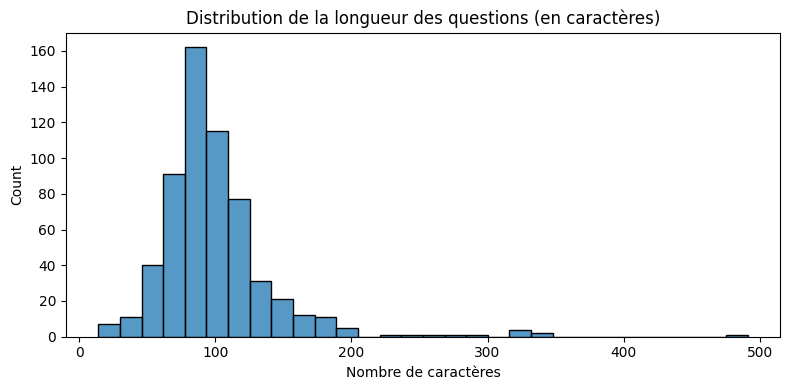

In [28]:
# Distribution des longueurs de questions
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(df["question"].str.len(), bins=30, ax=ax)
ax.set_title("Distribution de la longueur des questions (en caractères)")
ax.set_xlabel("Nombre de caractères")
plt.tight_layout()
plt.show()